# Arrhenius form

Why arrhenius?
1. Making k depend on temperature which was not the case in the normal kinbetic first order fitting, so k is calculated for each temnperature value

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.lines import Line2D
from matplotlib import rcParams
from scipy.signal import savgol_filter, find_peaks, correlate
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit, minimize
from sklearn.metrics import mean_squared_error, r2_score
import pywt
from datetime import datetime
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.stats import linregress
from scipy.stats import pearsonr
from scipy.constants import R
from matplotlib.patheffects import withStroke
from scipy.ndimage import gaussian_filter1d, uniform_filter1d
import seaborn as sns
from pathlib import Path

In [9]:
# === Plotting ===
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
legend_font = 13
dpi = 900

# Define custom colors
colors = {
    "raw": "#009F82",        # Teal blue
    "drift": "#D95F02",      # Classic orange
    "corrected": "#7570B3",  # Soft purple (keeps consistency)
    "sg": "#E7298A",         # Magenta pink for SG-filtered

    "dwt": '#2c7bb6',        # Dark Blue
    "first": '#e66101',      # Warm Orange – mid-performing
    "logi": '#d95f02',       # Deep Red
    "gomp": "#009F82",       # Teal blue

    "dual": "#999999"        # Gray (less prominent)
}

def format_ax(ax, xlabel="Elapsed time (h)", ylabel="Pressure (kPa)"):
    ax.set_xlabel(xlabel, fontsize=20)
    ax.set_ylabel(ylabel, fontsize=20)
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.2, labelsize=15)
    ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)
    ax.minorticks_on()
    ax.grid(axis='y', linestyle='--', alpha=0.8)

# M1 : 2,5mM at RT

# First order

Time-varying Arrhenius fit (single run):
  k0  = 1.05091e+42 1/h
  Ea  = 2467.30 L·atm/mol  (~250.00 kJ/mol)
  Pmax= 14.99 µmol
  R²   = 0.9355,  RMSE = 1.09 µmol


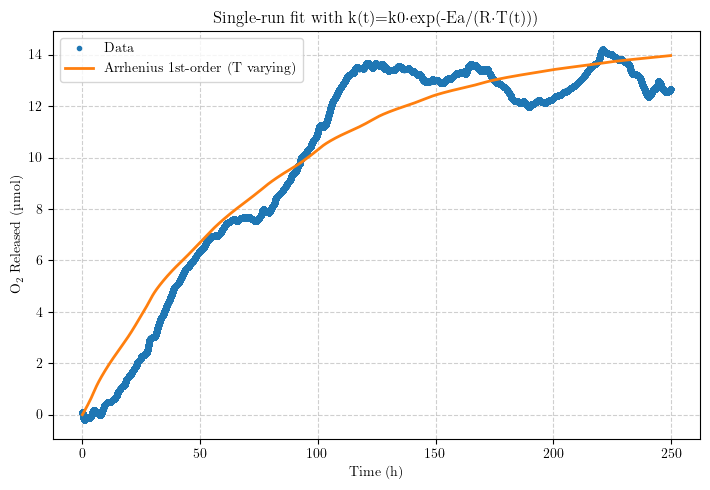

In [ ]:
# import numpy as np
# import pandas as pd
# from scipy.optimize import curve_fit

# # --- CONFIG / columns ---
# R = 0.082057  # L·atm·mol^-1·K^-1
# COL_O2 = "O2 Released (µmol) - Vg=4.0mL"
# COL_Tc = "calibrated temperature (C)"
# # NOTE: column label says "(s)" but values are HOURS; we use them as hours:
# COL_tH = "Time (s)"

# # --- Load one long run ---
# m1_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M1-2.5mM\data files\O2_RT_released_multi_volumes.csv"
# df = pd.read_csv(m1_csv)
# df.columns = [c.strip() for c in df.columns]

# # Pull vectors
# t = pd.to_numeric(df[COL_tH], errors="coerce").to_numpy()      # hours
# y = pd.to_numeric(df[COL_O2], errors="coerce").to_numpy()      # µmol
# Tc = pd.to_numeric(df[COL_Tc], errors="coerce").to_numpy()     # °C

# # Clean + sort + re-zero time
# m = np.isfinite(t) & np.isfinite(y) & np.isfinite(Tc)
# t, y, Tc = t[m], y[m], Tc[m]
# order = np.argsort(t)
# t, y, Tc = t[order], y[order], Tc[order]
# t = t - t.min()
# T = Tc + 273.15  # K

# # (Optional) light smoothing of temperature to reduce sensor noise (comment out if not needed)
# # from pandas import Series
# # T = pd.Series(T).rolling(window=5, min_periods=1, center=True).median().to_numpy()

# # ---- Helper: cumulative trapezoid integral for any vector (no SciPy dep needed) ----
# def cumtrapz_vec(f, x):
#     # f, x same shape; returns integral from x[0] to x[i]
#     dx = np.diff(x)
#     avg = 0.5 * (f[1:] + f[:-1])
#     out = np.empty_like(f, dtype=float)
#     out[0] = 0.0
#     out[1:] = np.cumsum(avg * dx)
#     return out

# # ---- Model with time-varying k(t) via Arrhenius on T(t) ----
# def arrhenius_timevarying_model(t_vec, k0, Ea_Latm_per_mol, Pmax):
#     # t_vec in hours; T is captured from closure
#     k_t = k0 * np.exp(-Ea_Latm_per_mol / (R * T))  # 1/h for each sample
#     K = cumtrapz_vec(k_t, t_vec)                    # integral_0^t k(t) dt
#     return Pmax * (1.0 - np.exp(-K))               # µmol

# # ---- Initial guesses + bounds ----
# Pmax0 = float(np.nanmax(y))
# # Rough guesses (adjust if needed)
# k0_guess = 1e-3                     # 1/h
# Ea_guess_Latm = (50_000/101.325)    # ~50 kJ/mol -> ~493 L·atm/mol

# p0 = [k0_guess, Ea_guess_Latm, Pmax0]
# Ea_lo = (1_000/101.325)             # ~1 kJ/mol
# Ea_hi = (250_000/101.325)           # ~250 kJ/mol
# lower = [0.0, Ea_lo, 0.0]
# upper = [np.inf, Ea_hi, np.inf]

# # ---- Fit ----
# popt, pcov = curve_fit(
#     lambda tt, k0, Ea, Pm: arrhenius_timevarying_model(tt, k0, Ea, Pm),
#     t, y, p0=p0, bounds=(lower, upper), maxfev=200000
# )
# k0_fit, Ea_fit_Latm, Pmax_fit = popt
# y_fit = arrhenius_timevarying_model(t, k0_fit, Ea_fit_Latm, Pmax_fit)

# # ---- Diagnostics ----
# resid = y - y_fit
# rss = float(np.sum(resid**2))
# ss_tot = float(np.sum((y - np.mean(y))**2))
# r2 = 1.0 - rss/ss_tot if ss_tot > 0 else np.nan
# rmse = float(np.sqrt(np.mean(resid**2)))

# print("Time-varying Arrhenius fit (single run):")
# print(f"  k0  = {k0_fit:.6g} 1/h")
# print(f"  Ea  = {Ea_fit_Latm:.2f} L·atm/mol  (~{Ea_fit_Latm*101.325/1000:.2f} kJ/mol)")
# print(f"  Pmax= {Pmax_fit:.4g} µmol")
# print(f"  R²   = {r2:.4f},  RMSE = {rmse:.4g} µmol")

# # (Optional) plot
# import matplotlib.pyplot as plt
# plt.figure(figsize=(7.2,5.0))
# plt.plot(t, y, "o", ms=3, label="Data")
# plt.plot(t, y_fit, "-", lw=2, label="Arrhenius 1st-order (T varying)")
# plt.xlabel("Time (h)")
# plt.ylabel("O$_2$ Released (µmol)")
# plt.title("Single-run fit with k(t)=k0·exp(-Ea/(R·T(t)))")
# plt.grid(True, linestyle="--", alpha=0.6)
# plt.legend()
# plt.tight_layout()
# plt.show()



,Model,P_max (µmol),k0 (1/h),Ea (J/mol),Half-Life at T̄ (s),Half-Life at T̄ (h),RMSE (µmol),R²,AIC,BIC
0,First-order (Arrhenius),14.774965,7.954260e+14,95652.36486,214394.274253,59.553965,1.09867,0.934483,169273.177901,169308.306344


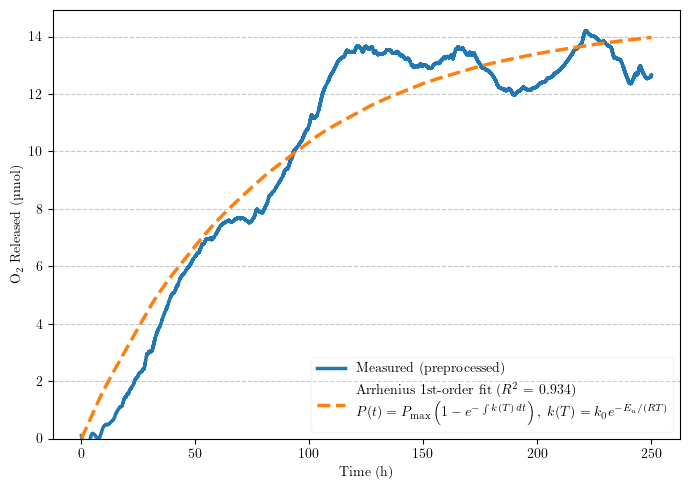

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score

# --- Handle SciPy version differences ---
try:
    from scipy.integrate import cumtrapz as cumulative_trapezoid
except ImportError:
    from scipy.integrate import cumulative_trapezoid

# ---- Load your preprocessed CSV ----
m1_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M1-2.5mM\data files\O2_RT_released_multi_volumes.csv"
df_m1 = pd.read_csv(m1_csv)
df_m1.columns = [c.strip() for c in df_m1.columns]

# Replace these with the series/column you want to fit
ngas_m1 = df_m1["O2 Released (µmol) - Vg=4.0mL"].values
time_m1 = df_m1["Time (s)"].values                    # actually hours
tempC_m1 = df_m1["calibrated temperature (C)"].values # °C

# --- Clean ---
mask = np.isfinite(time_m1) & np.isfinite(ngas_m1) & np.isfinite(tempC_m1)
t = np.asarray(time_m1[mask], dtype=float)
y = np.asarray(ngas_m1[mask], dtype=float)
T_C = np.asarray(tempC_m1[mask], dtype=float)
T_K = T_C + 273.15  # Kelvin

# Sort if needed
if np.any(np.diff(t) <= 0):
    order = np.argsort(t)
    t, y, T_K = t[order], y[order], T_K[order]

# Shift to start at zero
t0 = t.min()
t = t - t0

# --- Arrhenius-based first-order model ---
R = 8.314  # J/mol.K

def arrhenius_first_order_model(t, P_max, k0, Ea):
    k_T = k0 * np.exp(-Ea / (R * T_K))
    K_int = cumulative_trapezoid(k_T, t, initial=0.0)
    return P_max * (1.0 - np.exp(-K_int))

# --- Fit ---
Pmax0 = float(np.nanmax(y))
k0_guess = 1e-6
Ea_guess = 2.0e4

lower_bounds = [0.8 * Pmax0, 0.0, 0.0]
upper_bounds = [1.2 * Pmax0, np.inf, np.inf]

popt, pcov = curve_fit(
    arrhenius_first_order_model, t, y,
    p0=[Pmax0, k0_guess, Ea_guess],
    bounds=(lower_bounds, upper_bounds),
    maxfev=200000
)

P_max_fit, k0_fit, Ea_fit = popt
y_fit = arrhenius_first_order_model(t, *popt)

# --- Metrics ---
def aic(n, rss, k_params): return n * np.log(rss / n) + 2 * k_params
def bic(n, rss, k_params): return n * np.log(rss / n) + k_params * np.log(n)

n = len(y)
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)

Tmean = np.mean(T_K)
k_meanT = k0_fit * np.exp(-Ea_fit / (R * Tmean))
t_half_h = np.log(2.0) / k_meanT if k_meanT > 0 else np.inf
t_half_s = t_half_h * 3600.0

metrics = pd.DataFrame({
    "Model": ["First-order (Arrhenius)"],
    "P_max (µmol)": [P_max_fit],
    "k0 (1/h)": [k0_fit],
    "Ea (J/mol)": [Ea_fit],
    "Half-Life at T̄ (s)": [t_half_s],
    "Half-Life at T̄ (h)": [t_half_h],
    "RMSE (µmol)": [rmse],
    "R²": [r2],
    "AIC": [aic(n, rss, 3)],
    "BIC": [bic(n, rss, 3)],
})
display(metrics.round(6))

# --- Plot ---
plt.figure(figsize=(7, 5))
plt.plot(t + t0, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t + t0, y_fit, "--", lw=2.5,
         label=fr"Arrhenius 1st-order fit ($R^2$ = {r2:.3f})" + "\n" + 
               r"$P(t)=P_{\max}\left(1-e^{-\int k(T)\,dt}\right),\; k(T)=k_0 e^{-E_a/(RT)}$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()


# Logistic

,Model,P_max (µmol),k0 (1/h),Ea (J/mol),t0 (h),RMSE,R²,AIC,BIC
0,Logistic (Arrhenius),13.191009,143.367464,19999.311374,59.134338,0.768331,0.967958,-474037.615374,-473990.77745


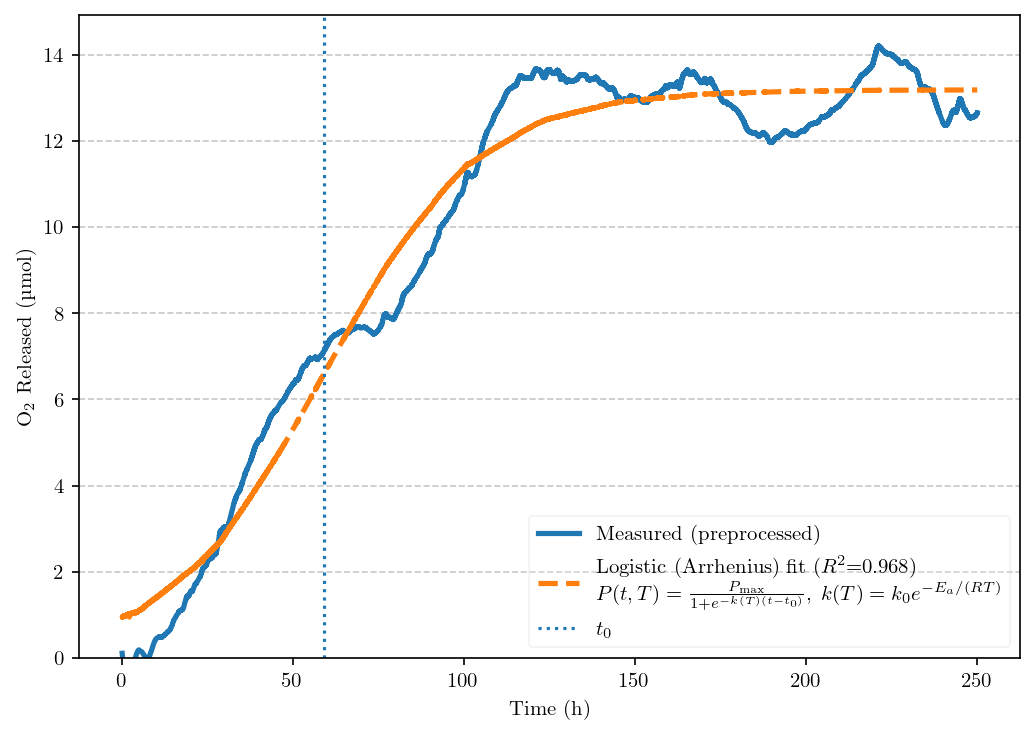

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, r2_score

# ---- Load your preprocessed CSV ----
mlogi_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M1-2.5mM\data files\O2_RT_released_multi_volumes.csv"
df_mlogi = pd.read_csv(mlogi_csv)
df_mlogi.columns = [c.strip() for c in df_mlogi.columns]

# Replace these with the series/column you want to fit
ngas_mlogi = df_mlogi["O2 Released (µmol) - Vg=4.0mL"].values
time_mlogi = df_mlogi["Time (s)"].values            # actually hours
tempC_mlogi = df_mlogi["calibrated temperature (C)"].values

# --- Clean NaNs/Infs ---
mask = np.isfinite(time_mlogi) & np.isfinite(ngas_mlogi) & np.isfinite(tempC_mlogi)
t = np.asarray(time_mlogi[mask], dtype=float)
y = np.asarray(ngas_mlogi[mask], dtype=float)
T_K = np.asarray(tempC_mlogi[mask], dtype=float) + 273.15  # Kelvin

# Sort if needed
if np.any(np.diff(t) <= 0):
    order = np.argsort(t)
    t, y, T_K = t[order], y[order], T_K[order]

# --- Arrhenius–logistic model ---
# P(t,T) = Pmax / (1 + exp( -k(T)*(t - t0) )),  k(T) = k0 * exp(-Ea/(R*T))
R = 8.314  # J/mol.K

def logistic_arrhenius(t, t0, k0, Ea, P_max):
    k_T = k0 * np.exp(-Ea / (R * T_K))
    return P_max / (1.0 + np.exp(-k_T * (t - t0)))

# --- Fit function with bounds from table ---
def fit_logistic_arrhenius(time, signal):
    P_max = float(np.max(signal))
    t0_init = time[np.argmin(np.abs(signal - P_max / 2.0))]
    k0_init = 1e-6
    Ea_init = 2.0e4

    def obj(p):
        t0, k0, Ea, Pm = p
        return mean_squared_error(signal, logistic_arrhenius(time, t0, k0, Ea, Pm))

    # bounds: t0 >= 0; k0 >= 0; Ea >= 0; P_max within ±20% of observed max
    bounds = ((0.0, None), (0.0, None), (0.0, None), (0.8 * P_max, 1.2 * P_max))

    res = minimize(obj, x0=[t0_init, k0_init, Ea_init, P_max], bounds=bounds, method="L-BFGS-B")
    popt = res.x
    fit = logistic_arrhenius(time, *popt)
    return popt, fit

# --- Run fit ---
popt, y_fit = fit_logistic_arrhenius(t, y)
t0_fit, k0_fit, Ea_fit, Pmax_fit = popt

# --- Metrics ---
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
n = len(y)
aic = n * np.log(rss / n) + 2 * 4   # params: t0, k0, Ea, Pmax
bic = n * np.log(rss / n) + 4 * np.log(n)

metrics = pd.DataFrame({
    "Model": ["Logistic (Arrhenius)"],
    "P_max (µmol)": [Pmax_fit],
    "k0 (1/h)": [k0_fit],
    "Ea (J/mol)": [Ea_fit],
    "t0 (h)": [t0_fit],
    "RMSE": [rmse],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic]
})
display(metrics.round(6))

# --- Plot ---
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t, y_fit, "--", lw=2.5,
         label=fr"Logistic (Arrhenius) fit ($R^2$={r2:.3f})" + "\n" +
               r"$P(t,T)=\frac{P_{\max}}{1+e^{-k(T)(t-t_0)}},\; k(T)=k_0 e^{-E_a/(RT)}$")
plt.axvline(t0_fit, linestyle=":", label=r"$t_0$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()


# Gompertz fit

,Model,P_max (µmol),k0 (1/h),Ea (J/mol),t0 (h),RMSE,R²,AIC,BIC
0,Gompertz (Arrhenius),13.341966,100.599505,19999.014264,44.361325,0.751336,0.96936,-514271.644867,-514224.806944


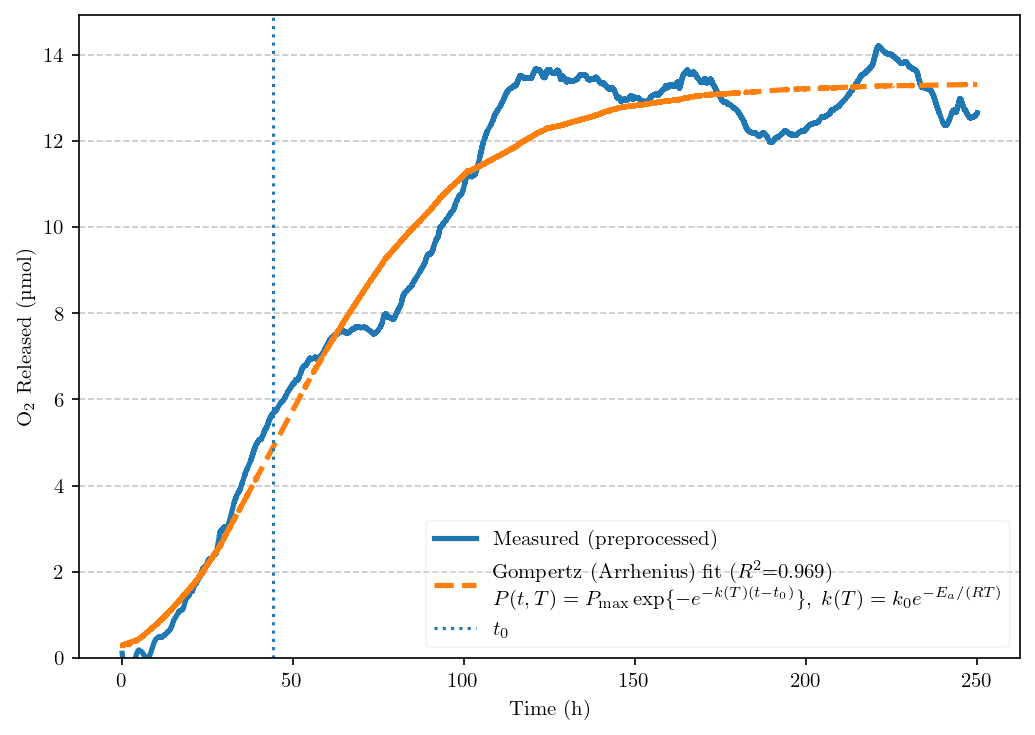

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, r2_score

# ---- Load CSV ----
m11gom_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M1-2.5mM\data files\O2_RT_released_multi_volumes.csv"
df_m11gom = pd.read_csv(m11gom_csv)
df_m11gom.columns = [c.strip() for c in df_m11gom.columns]

ngas = df_m11gom["O2 Released (µmol) - Vg=4.0mL"].values
time_h = df_m11gom["Time (s)"].values                 # actually hours
tempC  = df_m11gom["calibrated temperature (C)"].values

# ---- Clean ----
mask = np.isfinite(time_h) & np.isfinite(ngas) & np.isfinite(tempC)
t = np.asarray(time_h[mask], dtype=float)
y = np.asarray(ngas[mask], dtype=float)
T_K = np.asarray(tempC[mask], dtype=float) + 273.15   # Kelvin

# Ensure increasing time
if np.any(np.diff(t) <= 0):
    order = np.argsort(t)
    t, y, T_K = t[order], y[order], T_K[order]

# ---- Arrhenius–Gompertz ----
# P(t,T) = Pmax * exp( -exp( -k(T) * (t - t0) ) ),  where k(T)=k0*exp(-Ea/(R*T))
R = 8.314  # J/mol.K

def gompertz_arrhenius(t, t0, k0, Ea, Pmax):
    kT = k0 * np.exp(-Ea / (R * T_K))
    return Pmax * np.exp(-np.exp(-kT * (t - t0)))

# ---- Initial guesses ----
Pmax0 = float(np.max(y))
t0_init = float(t[np.argmin(np.abs(y - 0.5 * Pmax0))])
k0_init = 1e-6
Ea_init = 2.0e4

# ---- Bounds (same spirit as logistic Arrhenius): t0>=0, k0>=0, Ea>=0, Pmax ±20% ----
bounds = ((0.0, None), (0.0, None), (0.0, None), (0.8 * Pmax0, 1.2 * Pmax0))

# ---- Fit ----
def obj(p):
    t0, k0, Ea, Pm = p
    return mean_squared_error(y, gompertz_arrhenius(t, t0, k0, Ea, Pm))

res = minimize(obj, x0=[t0_init, k0_init, Ea_init, Pmax0], bounds=bounds, method="L-BFGS-B")
t0_fit, k0_fit, Ea_fit, Pmax_fit = res.x
y_fit = gompertz_arrhenius(t, t0_fit, k0_fit, Ea_fit, Pmax_fit)

# ---- Metrics ----
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
n = len(y)
aic = n * np.log(rss / n) + 2 * 4
bic = n * np.log(rss / n) + 4 * np.log(n)

metrics = pd.DataFrame({
    "Model": ["Gompertz (Arrhenius)"],
    "P_max (µmol)": [Pmax_fit],
    "k0 (1/h)": [k0_fit],
    "Ea (J/mol)": [Ea_fit],
    "t0 (h)": [t0_fit],
    "RMSE": [rmse],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic],
})
display(metrics.round(6))

# ---- Plot ----
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t, y_fit, "--", lw=2.5,
         label=fr"Gompertz (Arrhenius) fit ($R^2$={r2:.3f})" + "\n" +
               r"$P(t,T)=P_{\max}\exp\{-e^{-k(T)(t-t_0)}\},\; k(T)=k_0 e^{-E_a/(RT)}$")
plt.axvline(t0_fit, linestyle=":", label=r"$t_0$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()


# M2 : 2.18 mM at RT

# First order

,Model,P_max (µmol),k0 (1/h),Ea (J/mol),Half-Life at T̄ (s),Half-Life at T̄ (h),RMSE (µmol),R²,AIC,BIC
0,First-order (Arrhenius),10.987006,1.065932e+15,97065.952921,254721.554112,70.755987,0.951615,0.916316,-86233.620725,-86198.593873


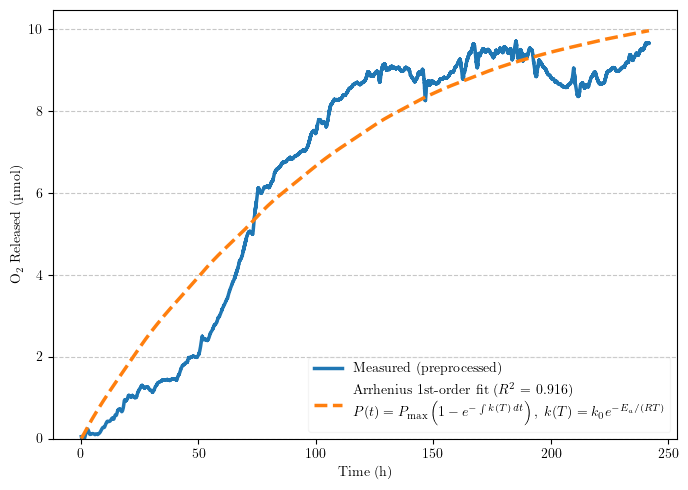

In [32]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score

# --- Handle SciPy version differences ---
try:
    from scipy.integrate import cumtrapz as cumulative_trapezoid
except ImportError:
    from scipy.integrate import cumulative_trapezoid

# ---- Load your preprocessed CSV ----
m2_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\RT\data files\O2_released_multi_volumes.csv"
df_m2 = pd.read_csv(m2_csv)
df_m2.columns = [c.strip() for c in df_m2.columns]

# Replace these with the series/column you want to fit
ngas_m2 = df_m2["O2 Released (µmol) - Vg=4.0mL"].values
time_m2 = df_m2["Time (s)"].values                    # actually hours
tempC_m2 = df_m2["calibrated temperature (C)"].values # °C

# --- Clean ---
mask = np.isfinite(time_m2) & np.isfinite(ngas_m2) & np.isfinite(tempC_m2)
t = np.asarray(time_m2[mask], dtype=float)
y = np.asarray(ngas_m2[mask], dtype=float)
T_C = np.asarray(tempC_m2[mask], dtype=float)
T_K = T_C + 273.15  # Kelvin

# Sort if needed
if np.any(np.diff(t) <= 0):
    order = np.argsort(t)
    t, y, T_K = t[order], y[order], T_K[order]

# Shift to start at zero
t0 = t.min()
t = t - t0

# --- Arrhenius-based first-order model ---
R = 8.314  # J/mol.K

def arrhenius_first_order_model(t, P_max, k0, Ea):
    k_T = k0 * np.exp(-Ea / (R * T_K))
    K_int = cumulative_trapezoid(k_T, t, initial=0.0)
    return P_max * (1.0 - np.exp(-K_int))

# --- Fit ---
Pmax0 = float(np.nanmax(y))
k0_guess = 1e-6
Ea_guess = 2.0e4

lower_bounds = [0.8 * Pmax0, 0.0, 0.0]
upper_bounds = [1.2 * Pmax0, np.inf, np.inf]

popt, pcov = curve_fit(
    arrhenius_first_order_model, t, y,
    p0=[Pmax0, k0_guess, Ea_guess],
    bounds=(lower_bounds, upper_bounds),
    maxfev=200000
)

P_max_fit, k0_fit, Ea_fit = popt
y_fit = arrhenius_first_order_model(t, *popt)

# --- Metrics ---
def aic(n, rss, k_params): return n * np.log(rss / n) + 2 * k_params
def bic(n, rss, k_params): return n * np.log(rss / n) + k_params * np.log(n)

n = len(y)
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)

Tmean = np.mean(T_K)
k_meanT = k0_fit * np.exp(-Ea_fit / (R * Tmean))
t_half_h = np.log(2.0) / k_meanT if k_meanT > 0 else np.inf
t_half_s = t_half_h * 3600.0

metrics = pd.DataFrame({
    "Model": ["First-order (Arrhenius)"],
    "P_max (µmol)": [P_max_fit],
    "k0 (1/h)": [k0_fit],
    "Ea (J/mol)": [Ea_fit],
    "Half-Life at T̄ (s)": [t_half_s],
    "Half-Life at T̄ (h)": [t_half_h],
    "RMSE (µmol)": [rmse],
    "R²": [r2],
    "AIC": [aic(n, rss, 3)],
    "BIC": [bic(n, rss, 3)],
})
display(metrics.round(6))

# --- Plot ---
plt.figure(figsize=(7, 5))
plt.plot(t + t0, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t + t0, y_fit, "--", lw=2.5,
         label=fr"Arrhenius 1st-order fit ($R^2$ = {r2:.3f})" + "\n" + 
               r"$P(t)=P_{\max}\left(1-e^{-\int k(T)\,dt}\right),\; k(T)=k_0 e^{-E_a/(RT)}$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()

# Logistic

,Model,P_max (µmol),k0 (1/h),Ea (J/mol),t0 (h),RMSE,R²,AIC,BIC
0,Logistic (Arrhenius),9.108623,180.203357,19999.154545,69.002277,0.277407,0.992889,-2.229734e+06,-2.229687e+06


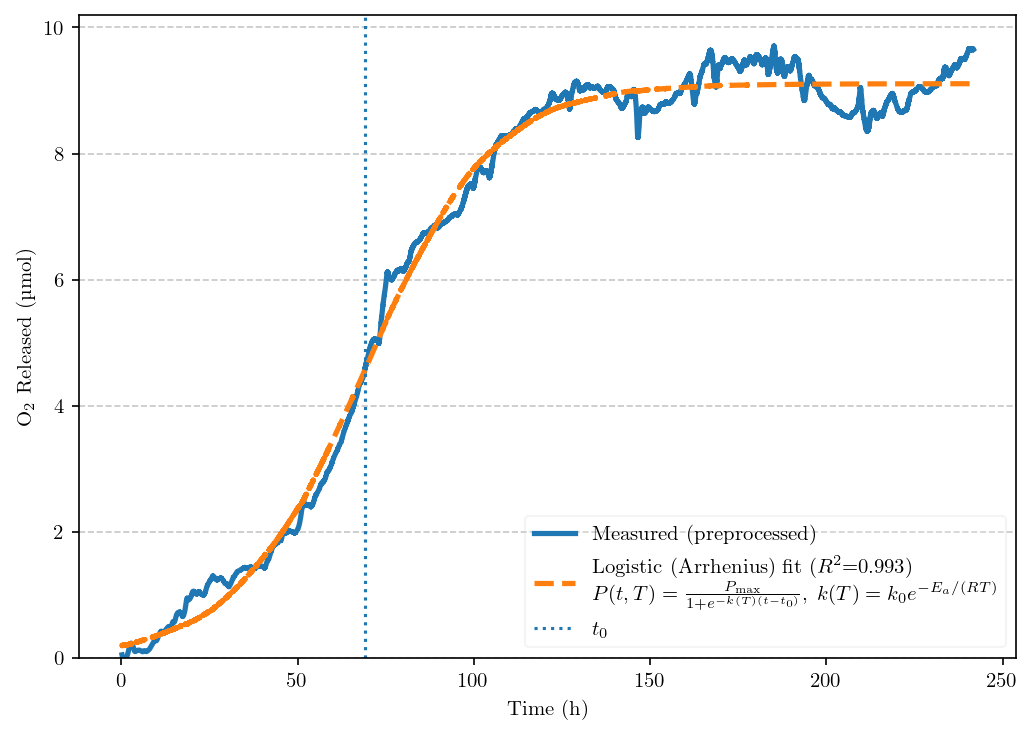

In [33]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, r2_score

# ---- Load your preprocessed CSV ----
mlogi2_csv =  r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\RT\data files\O2_released_multi_volumes.csv"
df_mlogi2 = pd.read_csv(mlogi2_csv)
df_mlogi2.columns = [c.strip() for c in df_mlogi2.columns]

# Replace these with the series/column you want to fit
ngas_mlogi2 = df_mlogi2["O2 Released (µmol) - Vg=4.0mL"].values
time_mlogi2 = df_mlogi2["Time (s)"].values            # actually hours
tempC_mlogi2 = df_mlogi2["calibrated temperature (C)"].values

# --- Clean NaNs/Infs ---
mask = np.isfinite(time_mlogi2) & np.isfinite(ngas_mlogi2) & np.isfinite(tempC_mlogi2)
t = np.asarray(time_mlogi2[mask], dtype=float)
y = np.asarray(ngas_mlogi2[mask], dtype=float)
T_K = np.asarray(tempC_mlogi2[mask], dtype=float) + 273.15  # Kelvin

# Sort if needed
if np.any(np.diff(t) <= 0):
    order = np.argsort(t)
    t, y, T_K = t[order], y[order], T_K[order]

# --- Arrhenius–logistic model ---
# P(t,T) = Pmax / (1 + exp( -k(T)*(t - t0) )),  k(T) = k0 * exp(-Ea/(R*T))
R = 8.314  # J/mol.K

def logistic_arrhenius(t, t0, k0, Ea, P_max):
    k_T = k0 * np.exp(-Ea / (R * T_K))
    return P_max / (1.0 + np.exp(-k_T * (t - t0)))

# --- Fit function with bounds from table ---
def fit_logistic_arrhenius(time, signal):
    P_max = float(np.max(signal))
    t0_init = time[np.argmin(np.abs(signal - P_max / 2.0))]
    k0_init = 1e-6
    Ea_init = 2.0e4

    def obj(p):
        t0, k0, Ea, Pm = p
        return mean_squared_error(signal, logistic_arrhenius(time, t0, k0, Ea, Pm))

    # bounds: t0 >= 0; k0 >= 0; Ea >= 0; P_max within ±20% of observed max
    bounds = ((0.0, None), (0.0, None), (0.0, None), (0.8 * P_max, 1.2 * P_max))

    res = minimize(obj, x0=[t0_init, k0_init, Ea_init, P_max], bounds=bounds, method="L-BFGS-B")
    popt = res.x
    fit = logistic_arrhenius(time, *popt)
    return popt, fit

# --- Run fit ---
popt, y_fit = fit_logistic_arrhenius(t, y)
t0_fit, k0_fit, Ea_fit, Pmax_fit = popt

# --- Metrics ---
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
n = len(y)
aic = n * np.log(rss / n) + 2 * 4   # params: t0, k0, Ea, Pmax
bic = n * np.log(rss / n) + 4 * np.log(n)

metrics = pd.DataFrame({
    "Model": ["Logistic (Arrhenius)"],
    "P_max (µmol)": [Pmax_fit],
    "k0 (1/h)": [k0_fit],
    "Ea (J/mol)": [Ea_fit],
    "t0 (h)": [t0_fit],
    "RMSE": [rmse],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic]
})
display(metrics.round(6))

# --- Plot ---
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t, y_fit, "--", lw=2.5,
         label=fr"Logistic (Arrhenius) fit ($R^2$={r2:.3f})" + "\n" +
               r"$P(t,T)=\frac{P_{\max}}{1+e^{-k(T)(t-t_0)}},\; k(T)=k_0 e^{-E_a/(RT)}$")
plt.axvline(t0_fit, linestyle=":", label=r"$t_0$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()


# Gompertz fit

,Model,P_max (µmol),k0 (1/h),Ea (J/mol),t0 (h),RMSE,R²,AIC,BIC
0,Gompertz (Arrhenius),9.240148,120.420784,19998.439421,57.492108,0.367006,0.987553,-1.743027e+06,-1.742980e+06


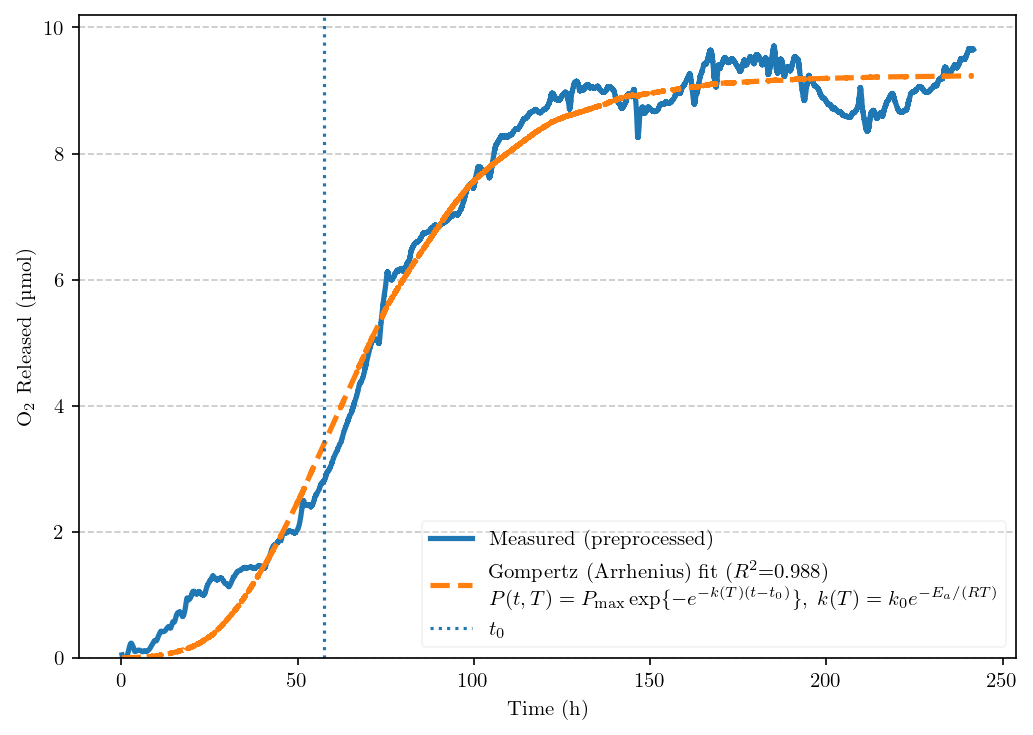

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, r2_score

# ---- Load CSV ----
m11gom2_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\RT\data files\O2_released_multi_volumes.csv"
df_m11gom2 = pd.read_csv(m11gom2_csv)
df_m11gom2.columns = [c.strip() for c in df_m11gom2.columns]

ngas2 = df_m11gom2["O2 Released (µmol) - Vg=4.0mL"].values
time_h2 = df_m11gom2["Time (s)"].values                 # actually hours
tempC2  = df_m11gom2["calibrated temperature (C)"].values

# ---- Clean ----
mask = np.isfinite(time_h2) & np.isfinite(ngas2) & np.isfinite(tempC2)
t = np.asarray(time_h2[mask], dtype=float)
y = np.asarray(ngas2[mask], dtype=float)
T_K = np.asarray(tempC2[mask], dtype=float) + 273.15   # Kelvin

# Ensure increasing time
if np.any(np.diff(t) <= 0):
    order = np.argsort(t)
    t, y, T_K = t[order], y[order], T_K[order]

# ---- Arrhenius–Gompertz ----
# P(t,T) = Pmax * exp( -exp( -k(T) * (t - t0) ) ),  where k(T)=k0*exp(-Ea/(R*T))
R = 8.314  # J/mol.K

def gompertz_arrhenius(t, t0, k0, Ea, Pmax):
    kT = k0 * np.exp(-Ea / (R * T_K))
    return Pmax * np.exp(-np.exp(-kT * (t - t0)))

# ---- Initial guesses ----
Pmax0 = float(np.max(y))
t0_init = float(t[np.argmin(np.abs(y - 0.5 * Pmax0))])
k0_init = 1e-6
Ea_init = 2.0e4

# ---- Bounds (same spirit as logistic Arrhenius): t0>=0, k0>=0, Ea>=0, Pmax ±20% ----
bounds = ((0.0, None), (0.0, None), (0.0, None), (0.8 * Pmax0, 1.2 * Pmax0))

# ---- Fit ----
def obj(p):
    t0, k0, Ea, Pm = p
    return mean_squared_error(y, gompertz_arrhenius(t, t0, k0, Ea, Pm))

res = minimize(obj, x0=[t0_init, k0_init, Ea_init, Pmax0], bounds=bounds, method="L-BFGS-B")
t0_fit, k0_fit, Ea_fit, Pmax_fit = res.x
y_fit = gompertz_arrhenius(t, t0_fit, k0_fit, Ea_fit, Pmax_fit)

# ---- Metrics ----
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
n = len(y)
aic = n * np.log(rss / n) + 2 * 4
bic = n * np.log(rss / n) + 4 * np.log(n)

metrics = pd.DataFrame({
    "Model": ["Gompertz (Arrhenius)"],
    "P_max (µmol)": [Pmax_fit],
    "k0 (1/h)": [k0_fit],
    "Ea (J/mol)": [Ea_fit],
    "t0 (h)": [t0_fit],
    "RMSE": [rmse],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic],
})
display(metrics.round(6))

# ---- Plot ----
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t, y_fit, "--", lw=2.5,
         label=fr"Gompertz (Arrhenius) fit ($R^2$={r2:.3f})" + "\n" +
               r"$P(t,T)=P_{\max}\exp\{-e^{-k(T)(t-t_0)}\},\; k(T)=k_0 e^{-E_a/(RT)}$")
plt.axvline(t0_fit, linestyle=":", label=r"$t_0$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()


# M2 : 2.18 mM at 37

# First order

,Model,P_max (µmol),k0 (1/h),Ea (J/mol),Half-Life at T̄ (s),Half-Life at T̄ (h),RMSE (µmol),R²,AIC,BIC
0,First-order (Arrhenius),10.383994,2.923314e+14,93246.012125,47763.097964,13.267527,0.206059,0.993703,-1.004612e+06,-1.004580e+06


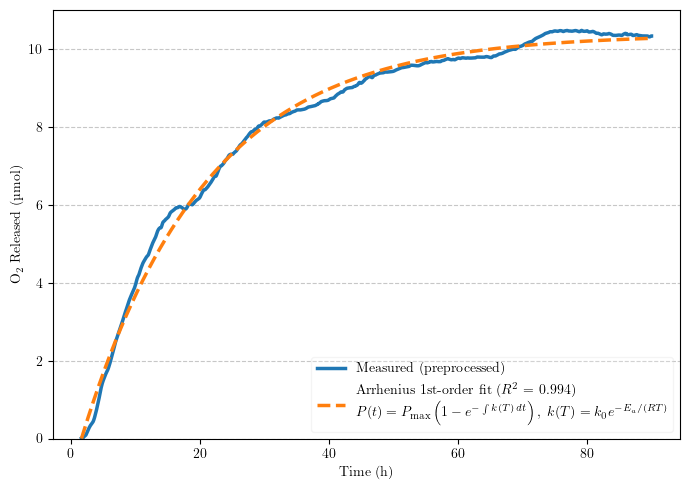

In [38]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score

# --- Handle SciPy version differences ---
try:
    from scipy.integrate import cumtrapz as cumulative_trapezoid
except ImportError:
    from scipy.integrate import cumulative_trapezoid

# ---- Load your preprocessed CSV ----
m22_csv =  r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\37 C\data files\Version 2\2_O2_37DEG_released_multi_volumes.csv"
df_m22 = pd.read_csv(m22_csv)
df_m22.columns = [c.strip() for c in df_m22.columns]

# Replace these with the series/column you want to fit
ngas_m22 = df_m22["O2 Released (µmol) - Vg=4.0mL"].values
time_m22 = df_m22["Time (h)"].values                    # actually hours
tempC_m22 = df_m22["calibrated temperature (C)"].values # °C

# --- Clean ---
mask = np.isfinite(time_m22) & np.isfinite(ngas_m22) & np.isfinite(tempC_m22)
t = np.asarray(time_m22[mask], dtype=float)
y = np.asarray(ngas_m22[mask], dtype=float)
T_C = np.asarray(tempC_m22[mask], dtype=float)
T_K = T_C + 273.15  # Kelvin

# Sort if needed
if np.any(np.diff(t) <= 0):
    order = np.argsort(t)
    t, y, T_K = t[order], y[order], T_K[order]

# Shift to start at zero
t0 = t.min()
t = t - t0

# --- Arrhenius-based first-order model ---
R = 8.314  # J/mol.K

def arrhenius_first_order_model(t, P_max, k0, Ea):
    k_T = k0 * np.exp(-Ea / (R * T_K))
    K_int = cumulative_trapezoid(k_T, t, initial=0.0)
    return P_max * (1.0 - np.exp(-K_int))

# --- Fit ---
Pmax0 = float(np.nanmax(y))
k0_guess = 1e-6
Ea_guess = 2.0e4

lower_bounds = [0.8 * Pmax0, 0.0, 0.0]
upper_bounds = [1.2 * Pmax0, np.inf, np.inf]

popt, pcov = curve_fit(
    arrhenius_first_order_model, t, y,
    p0=[Pmax0, k0_guess, Ea_guess],
    bounds=(lower_bounds, upper_bounds),
    maxfev=200000
)

P_max_fit, k0_fit, Ea_fit = popt
y_fit = arrhenius_first_order_model(t, *popt)

# --- Metrics ---
def aic(n, rss, k_params): return n * np.log(rss / n) + 2 * k_params
def bic(n, rss, k_params): return n * np.log(rss / n) + k_params * np.log(n)

n = len(y)
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)

Tmean = np.mean(T_K)
k_meanT = k0_fit * np.exp(-Ea_fit / (R * Tmean))
t_half_h = np.log(2.0) / k_meanT if k_meanT > 0 else np.inf
t_half_s = t_half_h * 3600.0

metrics = pd.DataFrame({
    "Model": ["First-order (Arrhenius)"],
    "P_max (µmol)": [P_max_fit],
    "k0 (1/h)": [k0_fit],
    "Ea (J/mol)": [Ea_fit],
    "Half-Life at T̄ (s)": [t_half_s],
    "Half-Life at T̄ (h)": [t_half_h],
    "RMSE (µmol)": [rmse],
    "R²": [r2],
    "AIC": [aic(n, rss, 3)],
    "BIC": [bic(n, rss, 3)],
})
display(metrics.round(6))

# --- Plot ---
plt.figure(figsize=(7, 5))
plt.plot(t + t0, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t + t0, y_fit, "--", lw=2.5,
         label=fr"Arrhenius 1st-order fit ($R^2$ = {r2:.3f})" + "\n" + 
               r"$P(t)=P_{\max}\left(1-e^{-\int k(T)\,dt}\right),\; k(T)=k_0 e^{-E_a/(RT)}$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()

# Logistic

,Model,P_max (µmol),k0 (1/h),Ea (J/mol),t0 (h),RMSE,R²,AIC,BIC
0,Logistic (Arrhenius),10.011529,247.108241,19999.382604,15.812483,0.499467,0.963,-441510.166115,-441467.486901


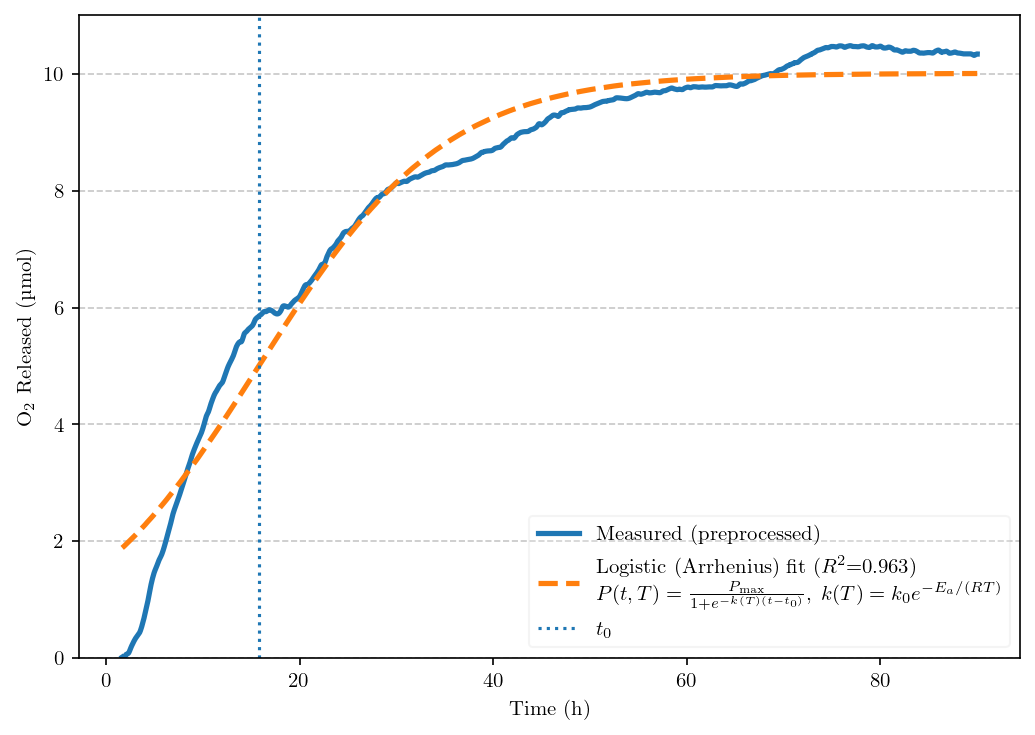

In [40]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, r2_score

# ---- Load your preprocessed CSV ----
mlogi22_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\37 C\data files\Version 2\2_O2_37DEG_released_multi_volumes.csv"
df_mlogi22 = pd.read_csv(mlogi22_csv)
df_mlogi22.columns = [c.strip() for c in df_mlogi22.columns]

# Replace these with the series/column you want to fit
ngas_mlogi22 = df_mlogi22["O2 Released (µmol) - Vg=4.0mL"].values
time_mlogi22 = df_mlogi22["Time (h)"].values            # actually hours
tempC_mlogi22 = df_mlogi22["calibrated temperature (C)"].values

# --- Clean NaNs/Infs ---
mask = np.isfinite(time_mlogi22) & np.isfinite(ngas_mlogi22) & np.isfinite(tempC_mlogi22)
t = np.asarray(time_mlogi22[mask], dtype=float)
y = np.asarray(ngas_mlogi22[mask], dtype=float)
T_K = np.asarray(tempC_mlogi22[mask], dtype=float) + 273.15  # Kelvin

# Sort if needed
if np.any(np.diff(t) <= 0):
    order = np.argsort(t)
    t, y, T_K = t[order], y[order], T_K[order]

# --- Arrhenius–logistic model ---
# P(t,T) = Pmax / (1 + exp( -k(T)*(t - t0) )),  k(T) = k0 * exp(-Ea/(R*T))
R = 8.314  # J/mol.K

def logistic_arrhenius(t, t0, k0, Ea, P_max):
    k_T = k0 * np.exp(-Ea / (R * T_K))
    return P_max / (1.0 + np.exp(-k_T * (t - t0)))

# --- Fit function with bounds from table ---
def fit_logistic_arrhenius(time, signal):
    P_max = float(np.max(signal))
    t0_init = time[np.argmin(np.abs(signal - P_max / 2.0))]
    k0_init = 1e-6
    Ea_init = 2.0e4

    def obj(p):
        t0, k0, Ea, Pm = p
        return mean_squared_error(signal, logistic_arrhenius(time, t0, k0, Ea, Pm))

    # bounds: t0 >= 0; k0 >= 0; Ea >= 0; P_max within ±20% of observed max
    bounds = ((0.0, None), (0.0, None), (0.0, None), (0.8 * P_max, 1.2 * P_max))

    res = minimize(obj, x0=[t0_init, k0_init, Ea_init, P_max], bounds=bounds, method="L-BFGS-B")
    popt = res.x
    fit = logistic_arrhenius(time, *popt)
    return popt, fit

# --- Run fit ---
popt, y_fit = fit_logistic_arrhenius(t, y)
t0_fit, k0_fit, Ea_fit, Pmax_fit = popt

# --- Metrics ---
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
n = len(y)
aic = n * np.log(rss / n) + 2 * 4   # params: t0, k0, Ea, Pmax
bic = n * np.log(rss / n) + 4 * np.log(n)

metrics = pd.DataFrame({
    "Model": ["Logistic (Arrhenius)"],
    "P_max (µmol)": [Pmax_fit],
    "k0 (1/h)": [k0_fit],
    "Ea (J/mol)": [Ea_fit],
    "t0 (h)": [t0_fit],
    "RMSE": [rmse],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic]
})
display(metrics.round(6))

# --- Plot ---
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t, y_fit, "--", lw=2.5,
         label=fr"Logistic (Arrhenius) fit ($R^2$={r2:.3f})" + "\n" +
               r"$P(t,T)=\frac{P_{\max}}{1+e^{-k(T)(t-t_0)}},\; k(T)=k_0 e^{-E_a/(RT)}$")
plt.axvline(t0_fit, linestyle=":", label=r"$t_0$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()

# Gompertz fit

,Model,P_max (µmol),k0 (1/h),Ea (J/mol),t0 (h),RMSE,R²,AIC,BIC
0,Gompertz (Arrhenius),10.126624,186.043565,19999.648707,10.736736,0.386663,0.977826,-604317.89348,-604275.214266


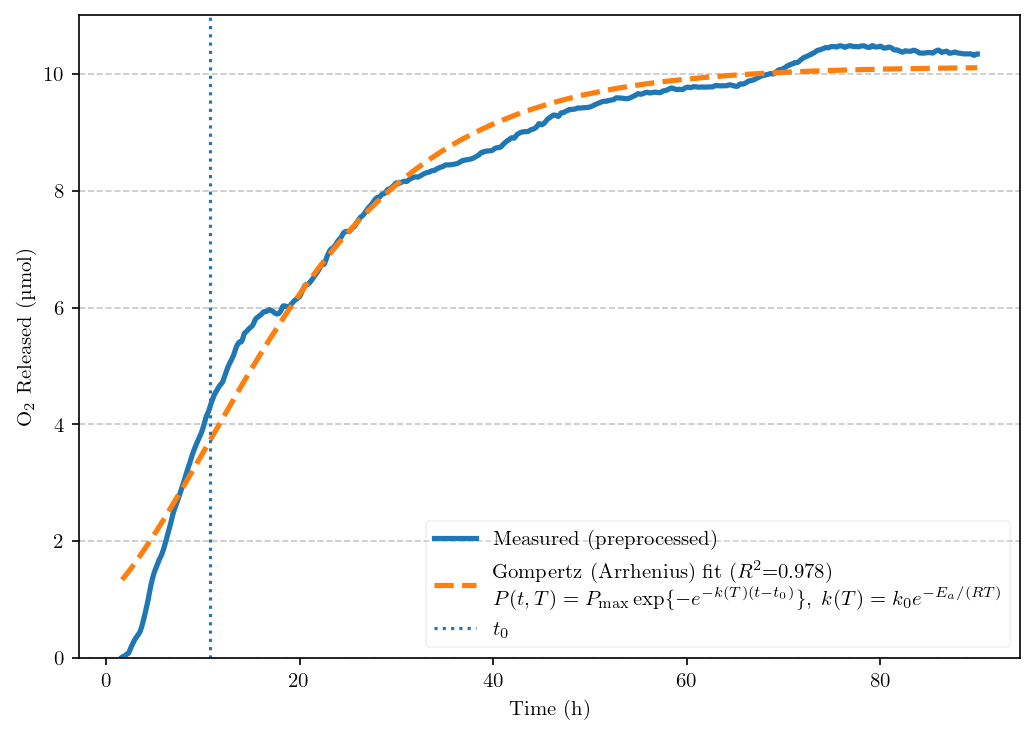

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, r2_score

# ---- Load CSV ----
m11gom21_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\37 C\data files\Version 2\2_O2_37DEG_released_multi_volumes.csv"
df_m11gom21 = pd.read_csv(m11gom21_csv)
df_m11gom21.columns = [c.strip() for c in df_m11gom21.columns]

ngas21 = df_m11gom21["O2 Released (µmol) - Vg=4.0mL"].values
time_h21 = df_m11gom21["Time (h)"].values                 # actually hours
tempC21  = df_m11gom21["calibrated temperature (C)"].values

# ---- Clean ----
mask = np.isfinite(time_h21) & np.isfinite(ngas21) & np.isfinite(tempC21)
t = np.asarray(time_h21[mask], dtype=float)
y = np.asarray(ngas21[mask], dtype=float)
T_K = np.asarray(tempC21[mask], dtype=float) + 273.15   # Kelvin

# Ensure increasing time
if np.any(np.diff(t) <= 0):
    order = np.argsort(t)
    t, y, T_K = t[order], y[order], T_K[order]

# ---- Arrhenius–Gompertz ----
# P(t,T) = Pmax * exp( -exp( -k(T) * (t - t0) ) ),  where k(T)=k0*exp(-Ea/(R*T))
R = 8.314  # J/mol.K

def gompertz_arrhenius(t, t0, k0, Ea, Pmax):
    kT = k0 * np.exp(-Ea / (R * T_K))
    return Pmax * np.exp(-np.exp(-kT * (t - t0)))

# ---- Initial guesses ----
Pmax0 = float(np.max(y))
t0_init = float(t[np.argmin(np.abs(y - 0.5 * Pmax0))])
k0_init = 1e-6
Ea_init = 2.0e4

# ---- Bounds (same spirit as logistic Arrhenius): t0>=0, k0>=0, Ea>=0, Pmax ±20% ----
bounds = ((0.0, None), (0.0, None), (0.0, None), (0.8 * Pmax0, 1.2 * Pmax0))

# ---- Fit ----
def obj(p):
    t0, k0, Ea, Pm = p
    return mean_squared_error(y, gompertz_arrhenius(t, t0, k0, Ea, Pm))

res = minimize(obj, x0=[t0_init, k0_init, Ea_init, Pmax0], bounds=bounds, method="L-BFGS-B")
t0_fit, k0_fit, Ea_fit, Pmax_fit = res.x
y_fit = gompertz_arrhenius(t, t0_fit, k0_fit, Ea_fit, Pmax_fit)

# ---- Metrics ----
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
n = len(y)
aic = n * np.log(rss / n) + 2 * 4
bic = n * np.log(rss / n) + 4 * np.log(n)

metrics = pd.DataFrame({
    "Model": ["Gompertz (Arrhenius)"],
    "P_max (µmol)": [Pmax_fit],
    "k0 (1/h)": [k0_fit],
    "Ea (J/mol)": [Ea_fit],
    "t0 (h)": [t0_fit],
    "RMSE": [rmse],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic],
})
display(metrics.round(6))

# ---- Plot ----
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t, y_fit, "--", lw=2.5,
         label=fr"Gompertz (Arrhenius) fit ($R^2$={r2:.3f})" + "\n" +
               r"$P(t,T)=P_{\max}\exp\{-e^{-k(T)(t-t_0)}\},\; k(T)=k_0 e^{-E_a/(RT)}$")
plt.axvline(t0_fit, linestyle=":", label=r"$t_0$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()

# M3 : 1.2 mM at RT

# First order

# Logistic

# Gompertz fit

# M3 : 1.2 mM at 37

# First order

# Logistic

# Gompertz fit